# **Exploration & Analyse de données - Préparation**

## **Imports**

In [1]:
# Import des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

# 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [19]:
# Chargement du dataset
df = pd.read_csv('../data/medquad.csv')

In [3]:
# Dimensions
print(f"Shape: {df.shape}")
print(f"Lignes: {df.shape[0]}, Colonnes: {df.shape[1]}")
print("\nColonnes:", df.columns.tolist())

# Info générale
print("\nInfo dataset:")
df.info()

# Aperçu premières lignes
print("\nAperçu:")
df.head()

Shape: (16412, 4)
Lignes: 16412, Colonnes: 4

Colonnes: ['question', 'answer', 'source', 'focus_area']

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 16412 entries, 0 to 16411
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   question    16412 non-null  str  
 1   answer      16407 non-null  str  
 2   source      16412 non-null  str  
 3   focus_area  16398 non-null  str  
dtypes: str(4)
memory usage: 513.0 KB

Aperçu:


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


In [4]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Manquants': missing, '%': missing_pct})
print("Valeurs manquantes:")
print(missing_df[missing_df['Manquants'] > 0])

Valeurs manquantes:
            Manquants         %
answer              5  0.030466
focus_area         14  0.085303


In [5]:
# Doublons
print(f"\nDoublons exacts: {df.duplicated().sum()}")
print(f"Doublons sur question: {df.duplicated('question').sum()}")
print(f"Doublons sur question+answer: {df.duplicated(['question', 'answer']).sum()}")


Doublons exacts: 48
Doublons sur question: 1428
Doublons sur question+answer: 48


In [7]:
# Types
print("\nTypes:")
print(df.dtypes)



Types:
question            str
answer              str
source              str
focus_area          str
question_len      int64
answer_len      float64
dtype: object


In [8]:
# Longueur des textes
df['question_len'] = df['question'].str.len()
df['answer_len'] = df['answer'].str.len()

print("\nStatistiques longueur questions:")
print(df['question_len'].describe())
print("\nStatistiques longueur réponses:")
print(df['answer_len'].describe())


Statistiques longueur questions:
count    16412.000000
mean        50.684438
std         16.925355
min         16.000000
25%         38.000000
50%         48.000000
75%         61.000000
max        191.000000
Name: question_len, dtype: float64

Statistiques longueur réponses:
count    16407.000000
mean      1303.452673
std       1656.694326
min          6.000000
25%        487.000000
50%        890.000000
75%       1589.000000
max      29046.000000
Name: answer_len, dtype: float64


In [9]:
print("Distribution par source:")
print(df['source'].value_counts())

Distribution par source:
source
GHR                  5430
GARD                 5394
NIDDK                1192
NINDS                1088
MPlusHealthTopics     981
NIHSeniorHealth       769
CancerGov             729
NHLBI                 559
CDC                   270
Name: count, dtype: int64


In [10]:
print("Top 20 focus_area:")
print(df['focus_area'].value_counts().head(20))

Top 20 focus_area:
focus_area
Breast Cancer                       53
Prostate Cancer                     43
Stroke                              35
Skin Cancer                         34
Alzheimer's Disease                 30
Colorectal Cancer                   29
Lung Cancer                         29
High Blood Cholesterol              28
Heart Attack                        28
Heart Failure                       28
Causes of Diabetes                  28
High Blood Pressure                 27
Parkinson's Disease                 25
Leukemia                            22
Osteoporosis                        21
Shingles                            21
Diabetes                            20
Age-related Macular Degeneration    20
Hemochromatosis                     20
Diabetic Retinopathy                19
Name: count, dtype: int64


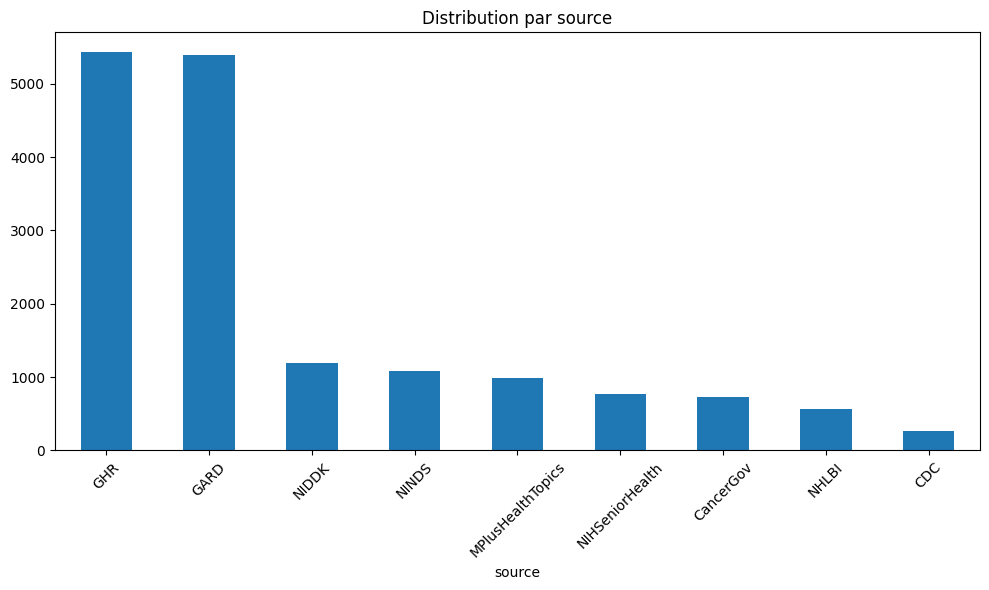

In [12]:
# Visualisation de la distribution des sources
plt.figure(figsize=(10,6))
df['source'].value_counts().plot(kind='bar')
plt.title('Distribution par source')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

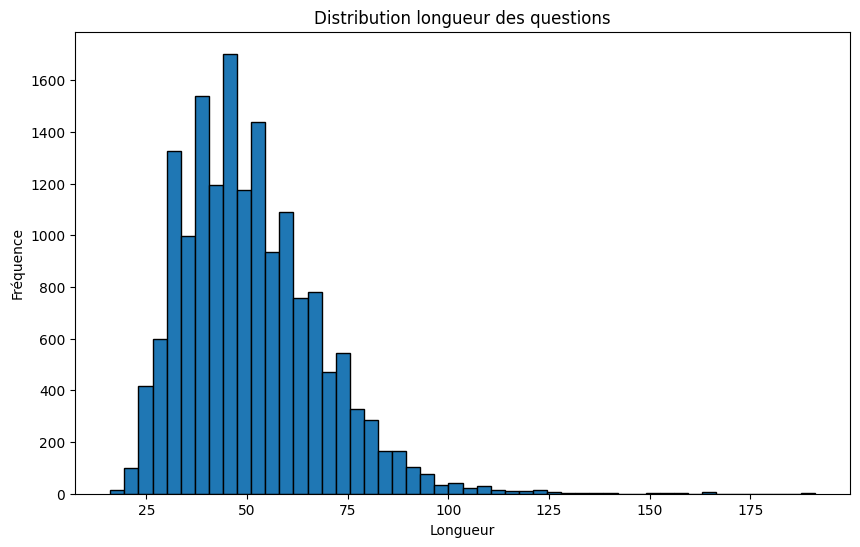

In [13]:
# Visualisation longueur des questions
plt.figure(figsize=(10,6))
plt.hist(df['question_len'], bins=50, edgecolor='black')
plt.title('Distribution longueur des questions')
plt.xlabel('Longueur')
plt.ylabel('Fréquence')
plt.show()

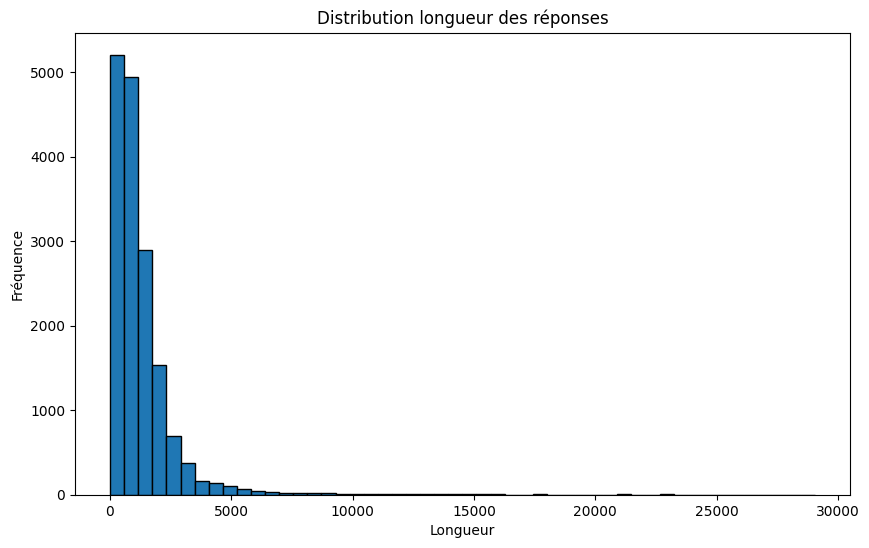

In [14]:
# Visualisation longueur des réponses
plt.figure(figsize=(10,6))
plt.hist(df['answer_len'], bins=50, edgecolor='black')
plt.title('Distribution longueur des réponses')
plt.xlabel('Longueur')
plt.ylabel('Fréquence')
plt.show()

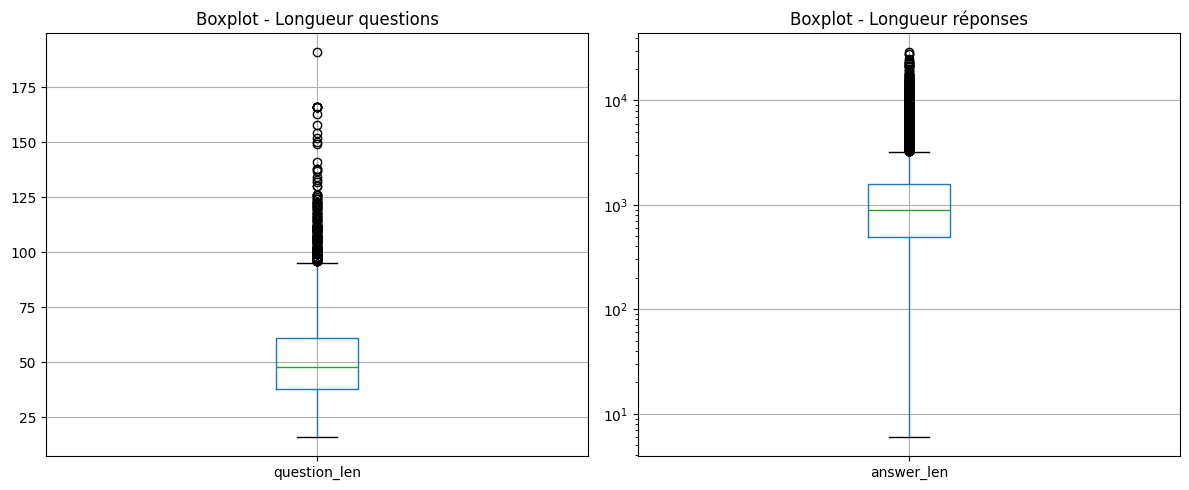

In [16]:
# Boxplot comparatif
fig, axes = plt.subplots(1, 2, figsize=(12,5))
df.boxplot(column='question_len', ax=axes[0])
axes[0].set_title('Boxplot - Longueur questions')
df.boxplot(column='answer_len', ax=axes[1])
axes[1].set_title('Boxplot - Longueur réponses')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

## **Constats Clés**

**Analyse/Observations**

- **Distribution des sources** : Déséquilibre marqué - GHR et GARD représentent ~66% des données. Risque de biais vers leurs pathologies couvertes.
- **Focus area** : Forte concentration sur cancers et maladies cardio-vasculaires. Nombreux sujets sous-représentés (apparition unique).
- **Qualité des données** : 1428 questions dupliquées (~9%), 48 doublons parfaits. Valeurs manquantes mineures (5 answer, 14 focus_area).
- **Longueur des textes** : Questions homogènes (~50 caractères). Réponses très hétérogènes (6 à 29000 caractères).

## **Décisions**

À partir des observations précédentes, plusieurs actions s'imposent pour préparer le dataset à la modélisation :

- **Nettoyer les doublons** : Éviter le sur-apprentissage et le biais sur les questions répétées
- **Gérer les valeurs manquantes** : Assurer l'intégrité des données d'entraînement
- **Traiter l'hétérogénéité des réponses** : Adapter aux contraintes de contexte des LLM
- **Équilibrer sources/focus_area** : Réduire les biais vers les catégories dominantes

In [32]:
# Supprimer les doublons parfaits
df_clean = df.drop_duplicates()
print(f"Lignes après suppression doublons parfaits: {len(df_clean)}")

Lignes après suppression doublons parfaits: 16364


In [33]:
# Compter occurrences par question
question_counts = df['question'].value_counts()
questions_frequentes = question_counts[question_counts > 1].index

print(f"Questions avec multiples réponses: {len(questions_frequentes)}")
print(f"Total de ces réponses multiples: {question_counts[questions_frequentes].sum()}")

Questions avec multiples réponses: 891
Total de ces réponses multiples: 2319


In [34]:
# Supprimer les réponses manquantes
df_clean = df_clean.dropna(subset=['answer'])
print(f"Après suppression answer manquants: {len(df_clean)}")

Après suppression answer manquants: 16359


In [35]:
# focus_area manquants
df_clean['focus_area'].isnull().sum()

np.int64(14)

In [36]:
# Imputer focus_area manquants
df_clean['focus_area'] = df_clean['focus_area'].fillna('Other')
print(f"Focus_area manquants après imputation: {df_clean['focus_area'].isnull().sum()}")
print(f"Taille finale du dataset: {len(df_clean)}")

Focus_area manquants après imputation: 0
Taille finale du dataset: 16359


## **Risques de fuite (data leakage)**

Lors de la préparation des données, il faut éviter que des informations du futur (test) ne contaminent l'entraînement, ce qui donnerait des performances artificiellement élevées.

- **Split temporel** : Non applicable (pas de timestamp)
- **Doublons entre train/test** : Risque que la même question apparaisse dans les deux ensembles, faussant les performances. Solution : split par question unique, pas par ligne.
- **Preprocessing avant split** : Tout calcul (normalisation, imputation) doit être fit sur train seulement, puis transform sur test.

### **Aperću du `df_clean`**

In [37]:
print(f"Shape finale: {df_clean.shape}")
print("\nColonnes:", df_clean.columns.tolist())

Shape finale: (16359, 4)

Colonnes: ['question', 'answer', 'source', 'focus_area']


In [38]:
print("Aperçu:")
df_clean.head()

Aperçu:


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


In [39]:
print("Valeurs manquantes:")
print(df_clean.isnull().sum())

Valeurs manquantes:
question      0
answer        0
source        0
focus_area    0
dtype: int64


In [40]:
print("Distribution des sources:")
print(df_clean['source'].value_counts())

Distribution des sources:
source
GHR                  5430
GARD                 5389
NIDDK                1144
NINDS                1088
MPlusHealthTopics     981
NIHSeniorHealth       769
CancerGov             729
NHLBI                 559
CDC                   270
Name: count, dtype: int64


In [42]:
df_clean['question_len'] = df_clean['question'].str.len()
df_clean['answer_len'] = df_clean['answer'].str.len()

print("Plage longueur réponses:")
print(f"Min: {df_clean['answer_len'].min()}, Max: {df_clean['answer_len'].max()}")
print(f"Mean: {df_clean['answer_len'].mean():.0f}, Median: {df_clean['answer_len'].median():.0f}")

Plage longueur réponses:
Min: 6, Max: 29046
Mean: 1297, Median: 888


In [43]:
# Sauvegarde du dataset nettoyé
df_clean.to_csv('../data/medquad_clean.csv', index=False)
print("Dataset sauvegardé: ../data/medquad_clean.csv")

Dataset sauvegardé: ../data/medquad_clean.csv
